# Notebook 04 — Results Table + Learning Curves

**Run after Notebook 03.**

Produces:
1. Full 3×3 ablation table (3 models × 3 aug modes)
2. Aug gain comparison showing GIN contribution
3. Learning curves for all 9 experiments
4. Per-center breakdown
5. Comparison vs FedBCa centralized baseline

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PROJECT_ROOT = Path('.').resolve().parent
paths        = json.loads((PROJECT_ROOT / 'paths.json').read_text())
EXPERIMENTS  = Path(paths['experiments'])
FIGURES      = PROJECT_ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

print('Paths loaded.')

Paths loaded.


In [2]:
# ─────────────────────────────────────────────
# CELL 2 — Load experiment results (EfficientNet, ResNet, Swin only)
# ─────────────────────────────────────────────
import torch

EXPERIMENTS_MAP = {
    'exp01_eff_noaug':       ('EfficientNet-B0', 'No Aug'),
    'exp02_eff_ginonly':     ('EfficientNet-B0', 'GIN Only'),
    'exp03_eff_fullaug':     ('EfficientNet-B0', 'Full Aug'),

    'exp04_res50_noaug':     ('ResNet50+CBAM',   'No Aug'),
    'exp05_res50_ginonly':   ('ResNet50+CBAM',   'GIN Only'),
    'exp06_res50_fullaug':   ('ResNet50+CBAM',   'Full Aug'),

    'exp10_swin_noaug':      ('Swin Hybrid',     'No Aug'),
    'exp11_swin_ginonly':    ('Swin Hybrid',     'GIN Only'),
    'exp12_swin_fullaug':    ('Swin Hybrid',     'Full Aug'),
}

results = {}

for exp_name, (model, aug) in EXPERIMENTS_MAP.items():

    ckpt_path = EXPERIMENTS / exp_name / 'checkpoint_best.pt'

    if not ckpt_path.exists():
        print(f'  [skip] {exp_name} — not yet trained')
        continue

    ckpt = torch.load(
        str(ckpt_path),
        map_location='cpu'
    )

    m = ckpt['metrics']

    results[exp_name] = {
        'model':    model,
        'aug':      aug,
        'dsc':      m.get('tumour_dsc', 0.0),
        'auc':      m.get('auc', 0.0),
        'combined': m.get('combined_score', 0.0),
        'epoch':    ckpt.get('epoch', 0),
    }

    print(
        f'  {exp_name}: '
        f'DSC={results[exp_name]["dsc"]:.4f} '
        f'AUC={results[exp_name]["auc"]:.4f}'
    )

print(f'\nLoaded {len(results)} experiments.')

C:\Users\Mayank\AppData\Local\Temp\ipykernel_1614240\257382605.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(


  exp01_eff_noaug: DSC=0.7551 AUC=0.7857
  exp02_eff_ginonly: DSC=0.7909 AUC=0.8571
  exp03_eff_fullaug: DSC=0.8088 AUC=0.7679
  exp04_res50_noaug: DSC=0.7652 AUC=0.7589
  exp05_res50_ginonly: DSC=0.7629 AUC=0.7411
  exp06_res50_fullaug: DSC=0.8217 AUC=0.8482
  exp10_swin_noaug: DSC=0.8209 AUC=0.8929
  exp11_swin_ginonly: DSC=0.8370 AUC=0.8571
  exp12_swin_fullaug: DSC=0.8123 AUC=0.8750

Loaded 9 experiments.


In [4]:
# ─────────────────────────────────────────────
# CELL 4 — Aug Gain Comparison (3 models)
# ─────────────────────────────────────────────
aug_pairs = [
    ('EfficientNet-B0', 'exp01_eff_noaug',   'exp02_eff_ginonly',   'exp03_eff_fullaug'),

    ('ResNet50+CBAM',   'exp04_res50_noaug', 'exp05_res50_ginonly', 'exp06_res50_fullaug'),

    ('Swin Hybrid',     'exp10_swin_noaug',  'exp11_swin_ginonly',  'exp12_swin_fullaug'),
]

print('='*75)
print('  AUGMENTATION GAIN TABLE (3 models × 3 conditions)')
print('='*75)

print(
    f'{"Model":<22} '
    f'{"Condition":<14} '
    f'{"DSC":>8} '
    f'{"AUC":>8} '
    f'{"ΔDSC":>8} '
    f'{"ΔAUC":>8}'
)

print('-'*75)

for model_name, no_aug, gin, full in aug_pairs:

    if no_aug not in results:
        continue

    base_dsc = results[no_aug]['dsc']
    base_auc = results[no_aug]['auc']

    print(
        f'{model_name:<22} '
        f'{"No Aug":<14} '
        f'{base_dsc:>8.4f} '
        f'{base_auc:>8.4f} '
        f'{"—":>8} '
        f'{"—":>8}'
    )

    if gin in results:

        gd = results[gin]['dsc'] - base_dsc
        ga = results[gin]['auc'] - base_auc

        print(
            f'{"":<22} '
            f'{"GIN Only":<14} '
            f'{results[gin]["dsc"]:>8.4f} '
            f'{results[gin]["auc"]:>8.4f} '
            f'{gd:>+8.4f} '
            f'{ga:>+8.4f}'
        )

    if full in results:

        fd = results[full]['dsc'] - base_dsc
        fa = results[full]['auc'] - base_auc

        print(
            f'{"":<22} '
            f'{"Full Aug":<14} '
            f'{results[full]["dsc"]:>8.4f} '
            f'{results[full]["auc"]:>8.4f} '
            f'{fd:>+8.4f} '
            f'{fa:>+8.4f}'
        )

    print('-'*75)

print('Full Aug = GIN + Elastic + BiasField + Gamma + Noise')

print('GIN Only = GIN augmentation in isolation')

  AUGMENTATION GAIN TABLE (3 models × 3 conditions)
Model                  Condition           DSC      AUC     ΔDSC     ΔAUC
---------------------------------------------------------------------------
EfficientNet-B0        No Aug           0.7551   0.7857        —        —
                       GIN Only         0.7909   0.8571  +0.0358  +0.0714
                       Full Aug         0.8088   0.7679  +0.0537  -0.0178
---------------------------------------------------------------------------
ResNet50+CBAM          No Aug           0.7652   0.7589        —        —
                       GIN Only         0.7629   0.7411  -0.0023  -0.0178
                       Full Aug         0.8217   0.8482  +0.0565  +0.0893
---------------------------------------------------------------------------
Swin Hybrid            No Aug           0.8209   0.8929        —        —
                       GIN Only         0.8370   0.8571  +0.0161  -0.0358
                       Full Aug         0.8123   0.875

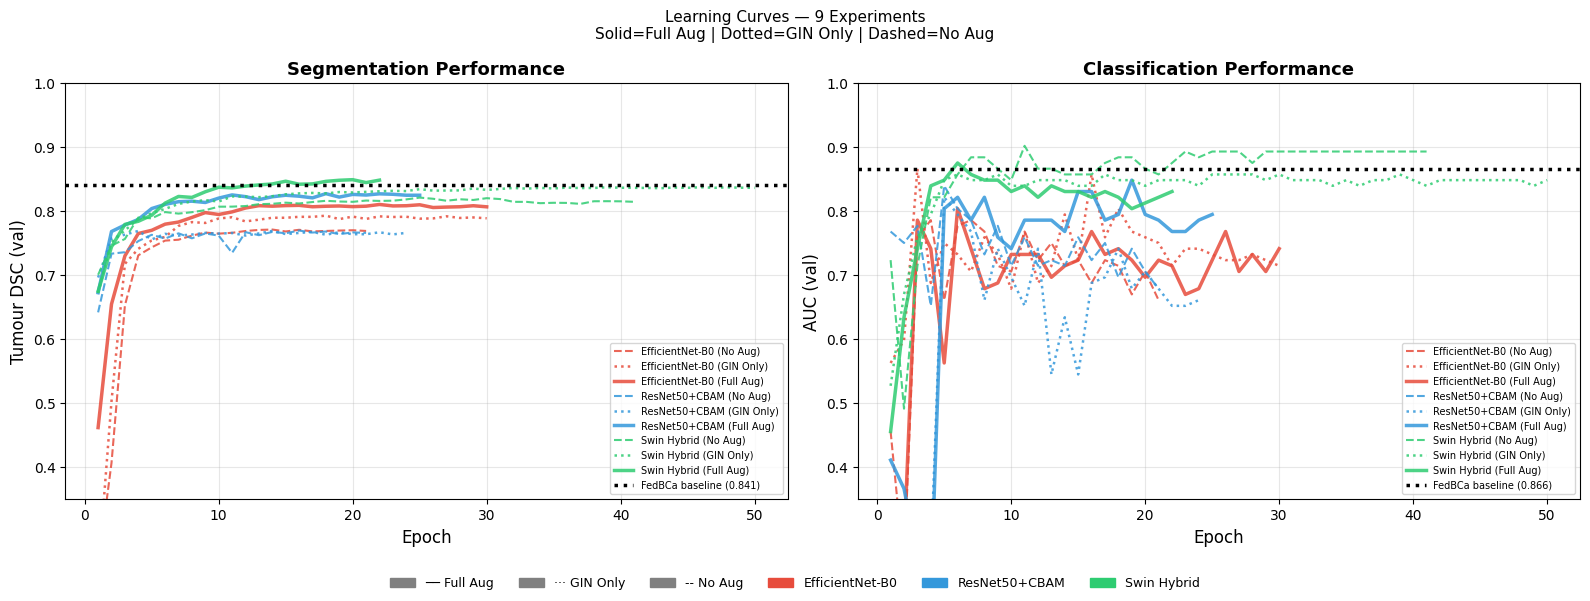

Saved: figures/learning_curves_all.png


In [5]:
# ─────────────────────────────────────────────
# CELL 5 — Learning Curves (9 experiments → 3 models only)
# ─────────────────────────────────────────────

COLORS = {
    'EfficientNet-B0': '#e74c3c',
    'ResNet50+CBAM':   '#3498db',
    'Swin Hybrid':     '#2ecc71',
}

STYLES = {
    'No Aug':   '--',
    'GIN Only': ':',
    'Full Aug': '-'
}

WIDTHS = {
    'No Aug':   1.5,
    'GIN Only': 1.8,
    'Full Aug': 2.5
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for exp_name, r in results.items():

    hist_path = EXPERIMENTS / exp_name / 'history.json'

    if not hist_path.exists():
        continue

    with open(hist_path) as f:
        h = json.load(f)

    ep = list(
        range(
            1,
            len(h.get('val_dsc', h.get('val_combined', []))) + 1
        )
    )

    dsc = h.get('val_dsc', [])

    auc = h.get('val_auc', [])

    c = COLORS.get(r['model'], '#7f8c8d')

    ls = STYLES.get(r['aug'], '-')

    lw = WIDTHS.get(r['aug'], 2.0)

    lbl = f"{r['model']} ({r['aug']})"

    if dsc:
        axes[0].plot(
            ep[:len(dsc)],
            dsc,
            color=c,
            ls=ls,
            lw=lw,
            label=lbl,
            alpha=0.85
        )

    if auc:
        axes[1].plot(
            ep[:len(auc)],
            auc,
            color=c,
            ls=ls,
            lw=lw,
            label=lbl,
            alpha=0.85
        )

for ax, tgt, yl, ttl in [
    (
        axes[0],
        0.841,
        'Tumour DSC (val)',
        'Segmentation Performance'
    ),
    (
        axes[1],
        0.866,
        'AUC (val)',
        'Classification Performance'
    ),
]:

    ax.axhline(
        tgt,
        color='black',
        ls=':',
        lw=2.5,
        label=f'FedBCa baseline ({tgt})'
    )

    ax.set_ylabel(yl, fontsize=12)

    ax.set_xlabel('Epoch', fontsize=12)

    ax.legend(
        fontsize=7,
        loc='lower right',
        ncol=1
    )

    ax.grid(True, alpha=0.3)

    ax.set_ylim(0.35, 1.0)

    ax.set_title(
        ttl,
        fontsize=13,
        fontweight='bold'
    )

# ─────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────

handles = [
    mpatches.Patch(
        color='gray',
        label='── Full Aug'
    ),

    mpatches.Patch(
        color='gray',
        label='··· GIN Only'
    ),

    mpatches.Patch(
        color='gray',
        label='-- No Aug'
    ),

    mpatches.Patch(
        color=COLORS['EfficientNet-B0'],
        label='EfficientNet-B0'
    ),

    mpatches.Patch(
        color=COLORS['ResNet50+CBAM'],
        label='ResNet50+CBAM'
    ),

    mpatches.Patch(
        color=COLORS['Swin Hybrid'],
        label='Swin Hybrid'
    ),
]

fig.legend(
    handles=handles,
    loc='lower center',
    ncol=6,
    fontsize=9,
    frameon=False
)

plt.suptitle(
    'Learning Curves — 9 Experiments\n'
    'Solid=Full Aug | Dotted=GIN Only | Dashed=No Aug',
    fontsize=11
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(
    FIGURES / 'learning_curves_all.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

print('Saved: figures/learning_curves_all.png')

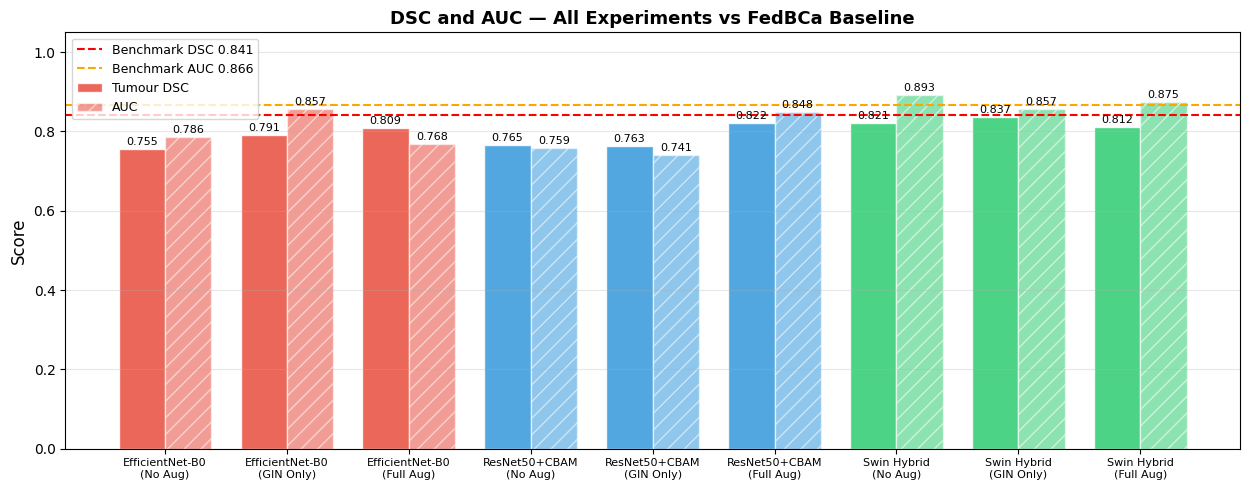

Saved: figures/bar_comparison.png


In [6]:
# ─────────────────────────────────────────────
# CELL 6 — Bar chart: DSC and AUC comparison
# ─────────────────────────────────────────────
available = [(k,v) for k,v in results.items() if v['dsc'] > 0]
if not available:
    print('No experiments completed yet.')
else:
    names = [f"{v['model']}\n({v['aug']})" for _,v in available]
    dscs  = [v['dsc'] for _,v in available]
    aucs  = [v['auc'] for _,v in available]
    colors = [COLORS.get(v['model'], '#7f8c8d') for _,v in available]

    x = np.arange(len(names))
    w = 0.38

    fig, ax = plt.subplots(figsize=(max(10, len(names)*1.4), 5))
    bars1 = ax.bar(x - w/2, dscs, w, label='Tumour DSC', color=colors, alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + w/2, aucs, w, label='AUC',        color=colors, alpha=0.55, edgecolor='white', hatch='//')

    ax.axhline(0.841, color='red',    ls='--', lw=1.5, label='Benchmark DSC 0.841')
    ax.axhline(0.866, color='orange', ls='--', lw=1.5, label='Benchmark AUC 0.866')

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('DSC and AUC — All Experiments vs FedBCa Baseline', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES / 'bar_comparison.png', dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved: figures/bar_comparison.png')